# IPL Performance Analytics — Data Cleaning

## 1. Cleaning objective

This notebook creates an auditable analytical layer from the two raw IPL CSV files. It standardizes only documented identifiers and adds fields required for correct downstream analysis. It does not calculate performance metrics, rankings, strike rates, economy rates, or other Phase 6 features.

## 2. Load raw data

Paths are derived from the project structure. The source CSVs are read without writes or in-place mutation.

In [1]:
from pathlib import Path
import hashlib
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
%matplotlib inline

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_cleaning import (CITY_NAME_MAP, ILLEGAL_DELIVERY_EXTRA_TYPES, TEAM_NAME_MAP, VENUE_NAME_MAP, VENUE_TO_CITY_FILL, clean_deliveries, clean_matches, save_clean_data, validate_cleaned_data)
from src.data_loader import load_raw_data

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")
matches_raw, deliveries_raw = load_raw_data(PROJECT_ROOT)
display(pd.DataFrame({"rows": [len(matches_raw), len(deliveries_raw)], "columns": [matches_raw.shape[1], deliveries_raw.shape[1]]}, index=["matches_raw", "deliveries_raw"]))

,rows,columns
matches_raw,1095,20
deliveries_raw,260920,17


## 3. Preserve raw data principle

The raw files are immutable source data. SHA-256 hashes are recorded before cleaning and checked again after export. All cleaning functions operate on copies.

In [2]:
def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

raw_paths = {"matches.csv": PROJECT_ROOT / "data/raw/matches.csv", "deliveries.csv": PROJECT_ROOT / "data/raw/deliveries.csv"}
raw_hashes_before = {name: sha256(path) for name, path in raw_paths.items()}
print("Raw hashes recorded; cleaning functions receive copies only.")

Raw hashes recorded; cleaning functions receive copies only.


## 4. Date cleaning

Source text is preserved as `date_raw`. `match_date` is parsed with `%Y-%m-%d`; calendar components support downstream filters. Any parse failure raises an error.

In [3]:
matches_clean = clean_matches(matches_raw)
date_check = pd.Series({"source_rows": len(matches_raw), "parsed_dates": matches_clean["match_date"].notna().sum(), "parse_failures": matches_clean["match_date"].isna().sum()}, name="count")
display(date_check.to_frame())
display(matches_clean[["date_raw", "match_date", "match_year", "match_month", "match_day"]].head())

,count
source_rows,1095
parsed_dates,1095
parse_failures,0


,date_raw,match_date,match_year,match_month,match_day
0,2008-04-18,2008-04-18,2008,4,18
1,2008-04-19,2008-04-19,2008,4,19
2,2008-04-19,2008-04-19,2008,4,19
3,2008-04-20,2008-04-20,2008,4,20
4,2008-04-20,2008-04-20,2008,4,20


## 5. Season standardization

`season_raw` preserves the source label. `season_standard` preserves the same IPL season identity after whitespace validation. `season_start_year` is the first calendar year, not a replacement for the season label.

In [4]:
season_comparison = matches_clean.groupby(["season_raw", "season_standard", "season_start_year"], dropna=False).size().rename("matches").reset_index()
display(season_comparison)
assert matches_clean["season_raw"].nunique() == matches_clean["season_standard"].nunique() == 17

,season_raw,season_standard,season_start_year,matches
0,2007/08,2007/08,2007,58
1,2009,2009,2009,57
2,2009/10,2009/10,2009,60
3,2011,2011,2011,73
4,2012,2012,2012,74
5,2013,2013,2013,76
6,2014,2014,2014,60
7,2015,2015,2015,59
8,2016,2016,2016,60
9,2017,2017,2017,59


## 6. Team-name standardization

Four reviewed rules combine three franchise renames and one Rising Pune variation. Gujarat Lions/Titans, Pune Warriors/Rising Pune, Deccan Chargers/Sunrisers Hyderabad, and Kochi/other teams remain distinct. Raw and standardized values are both retained.

In [5]:
deliveries_clean = clean_deliveries(deliveries_raw)
team_mapping_table = pd.DataFrame(TEAM_NAME_MAP.items(), columns=["raw_team_name", "standard_team_name"])
match_team_columns = ["team1", "team2", "toss_winner", "winner"]
delivery_team_columns = ["batting_team", "bowling_team"]
team_mapping_table["affected_occurrences"] = team_mapping_table["raw_team_name"].map(lambda name: sum(matches_raw[column].eq(name).sum() for column in match_team_columns) + sum(deliveries_raw[column].eq(name).sum() for column in delivery_team_columns))
display(team_mapping_table)
display(pd.Series({"raw_team_values": len(set(matches_clean["team1_raw"]) | set(matches_clean["team2_raw"])), "standard_team_values": len(set(matches_clean["team1_standard"]) | set(matches_clean["team2_standard"]))}, name="count").to_frame())

,raw_team_name,standard_team_name,affected_occurrences
0,Delhi Daredevils,Delhi Capitals,37819
1,Kings XI Punjab,Punjab Kings,45492
2,Royal Challengers Bangalore,Royal Challengers Bengaluru,57032
3,Rising Pune Supergiants,Rising Pune Supergiant,3221


,count
raw_team_values,19
standard_team_values,15


## 7. Venue standardization

Eighteen explicit mappings remove punctuation/city-suffix variants and consolidate reviewed Mohali labels. Historical renames such as Feroz Shah Kotla/Arun Jaitley Stadium remain separate pending a broader identity policy.

In [6]:
venue_mapping_table = pd.DataFrame(VENUE_NAME_MAP.items(), columns=["venue_raw", "venue_standard"])
venue_mapping_table["affected_matches"] = venue_mapping_table["venue_raw"].map(matches_raw["venue"].value_counts()).astype(int)
display(venue_mapping_table)
display(pd.Series({"raw_venue_values": matches_clean["venue_raw"].nunique(), "standard_venue_values": matches_clean["venue_standard"].nunique(), "matches_changed": matches_clean["venue_raw"].ne(matches_clean["venue_standard"]).sum()}, name="count").to_frame())

,venue_raw,venue_standard,affected_matches
0,"Arun Jaitley Stadium, Delhi",Arun Jaitley Stadium,16
1,"Brabourne Stadium, Mumbai",Brabourne Stadium,17
2,"Dr DY Patil Sports Academy, Mumbai",Dr DY Patil Sports Academy,20
3,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,2
4,"Eden Gardens, Kolkata",Eden Gardens,16
5,"Himachal Pradesh Cricket Association Stadium, ...",Himachal Pradesh Cricket Association Stadium,4
6,"M Chinnaswamy Stadium, Bengaluru",M Chinnaswamy Stadium,14
7,M.Chinnaswamy Stadium,M Chinnaswamy Stadium,15
8,"MA Chidambaram Stadium, Chepauk",MA Chidambaram Stadium,48
9,"MA Chidambaram Stadium, Chepauk, Chennai",MA Chidambaram Stadium,28


,count
raw_venue_values,58
standard_venue_values,40
matches_changed,361


## 8. City standardization

`Bangalore` becomes `Bengaluru`. Missing cities are filled only for Dubai International Cricket Stadium and Sharjah Cricket Stadium because the location is explicit and confirmed by other rows. `city_raw` retains original values and nulls.

In [7]:
city_decisions = pd.DataFrame([{"rule": "name mapping", "source": raw, "result": standard, "affected_rows": int(matches_clean["city_raw"].eq(raw).sum())} for raw, standard in CITY_NAME_MAP.items()] + [{"rule": "fill missing from unambiguous venue", "source": venue, "result": city, "affected_rows": int((matches_clean["city_raw"].isna() & matches_clean["venue_standard"].eq(venue)).sum())} for venue, city in VENUE_TO_CITY_FILL.items()])
display(city_decisions)
display(pd.Series({"raw_unique_non_null": matches_clean["city_raw"].nunique(), "standard_unique_non_null": matches_clean["city_standard"].nunique(), "raw_missing": matches_clean["city_raw"].isna().sum(), "standard_missing": matches_clean["city_standard"].isna().sum()}, name="count").to_frame())

,rule,source,result,affected_rows
0,name mapping,Bangalore,Bengaluru,65
1,fill missing from unambiguous venue,Dubai International Cricket Stadium,Dubai,33
2,fill missing from unambiguous venue,Sharjah Cricket Stadium,Sharjah,18


,count
raw_unique_non_null,36
standard_unique_non_null,35
raw_missing,51
standard_missing,0


## 9. Missing-value handling

No global fill is used. Winner and Player-of-the-Match remain null for no-results; margins remain null for ties/no-results; `method` remains null without D/L; and delivery extras/dismissal/fielder nulls retain their conditional meaning. Only 51 unambiguous city values are filled in `city_standard`.

In [8]:
missing_decisions = pd.DataFrame([
    ("city", matches_clean["city_raw"].isna().sum(), matches_clean["city_standard"].isna().sum(), "Fill only Dubai/Sharjah from venue"),
    ("winner", matches_clean["winner_raw"].isna().sum(), matches_clean["winner_standard"].isna().sum(), "Preserve for no-results"),
    ("player_of_match", matches_raw["player_of_match"].isna().sum(), matches_clean["player_of_match"].isna().sum(), "Preserve for no-results"),
    ("result_margin", matches_raw["result_margin"].isna().sum(), matches_clean["result_margin"].isna().sum(), "Preserve for ties/no-results"),
    ("method", matches_raw["method"].isna().sum(), matches_clean["method"].isna().sum(), "Preserve when D/L does not apply"),
    ("extras_type", deliveries_raw["extras_type"].isna().sum(), deliveries_clean["extras_type"].isna().sum(), "Preserve without extras"),
    ("player_dismissed", deliveries_raw["player_dismissed"].isna().sum(), deliveries_clean["player_dismissed"].isna().sum(), "Preserve without dismissal"),
    ("fielder", deliveries_raw["fielder"].isna().sum(), deliveries_clean["fielder"].isna().sum(), "Preserve when not applicable"),
], columns=["field", "missing_before", "missing_after", "decision"])
display(missing_decisions)

,field,missing_before,missing_after,decision
0,city,51,0,Fill only Dubai/Sharjah from venue
1,winner,5,5,Preserve for no-results
2,player_of_match,5,5,Preserve for no-results
3,result_margin,19,19,Preserve for ties/no-results
4,method,1074,1074,Preserve when D/L does not apply
5,extras_type,246795,246795,Preserve without extras
6,player_dismissed,247970,247970,Preserve without dismissal
7,fielder,251566,251566,Preserve when not applicable


## 10. Delivery-level cleaning

Every delivery remains. `is_legal_delivery` is false only for `wides` and `noballs`; byes, leg-byes, penalties, and ordinary deliveries are legal. `legal_ball` is the equivalent 1/0 field. Ball numbers above six and overs 0–19 are retained.

In [9]:
legal_delivery_summary = pd.Series({"recorded_deliveries": len(deliveries_clean), "legal_deliveries": deliveries_clean["is_legal_delivery"].sum(), "illegal_deliveries": (~deliveries_clean["is_legal_delivery"]).sum(), "wides": deliveries_clean["extras_type"].eq("wides").sum(), "no_balls": deliveries_clean["extras_type"].eq("noballs").sum(), "ball_above_6_rows_preserved": deliveries_clean["ball"].gt(6).sum()}, name="count")
display(legal_delivery_summary.to_frame())
display(deliveries_clean[["extras_type", "is_legal_delivery", "legal_ball"]].value_counts(dropna=False).to_frame("rows"))

,count
recorded_deliveries,260920
legal_deliveries,251471
illegal_deliveries,9449
wides,8380
no_balls,1069
ball_above_6_rows_preserved,9340


,,,rows
extras_type,is_legal_delivery,legal_ball,
NaN,True,1,246795
wides,False,0,8380
legbyes,True,1,4001
noballs,False,0,1069
byes,True,1,673
penalty,True,1,2


## 11. Data types

Identifiers and run fields remain integers, `match_date` is datetime, the legal flag is boolean, and cleaned labels use Pandas string dtype in memory.

In [10]:
display(matches_clean.dtypes.astype(str).to_frame("dtype"))
display(deliveries_clean.dtypes.astype(str).to_frame("dtype"))

,dtype
match_id,int64
season_raw,string
season_standard,string
season_start_year,int64
date_raw,str
match_date,datetime64[us]
match_year,int64
match_month,int64
match_day,int64
match_type,str


,dtype
match_id,int64
inning,int64
batting_team_raw,string
batting_team_standard,string
bowling_team_raw,string
bowling_team_standard,string
over,int64
ball,int64
batter,str
bowler,str


## 12. Before/after profiling

Row counts stay unchanged. Category counts decrease only where explicit mappings consolidate equivalent labels.

,measure,before,after,change
0,match rows,1095,1095,0
1,delivery rows,260920,260920,0
2,season labels,17,17,0
3,team labels,19,15,-4
4,venue labels,58,40,-18
5,city labels,36,35,-1
6,missing city values,51,0,-51


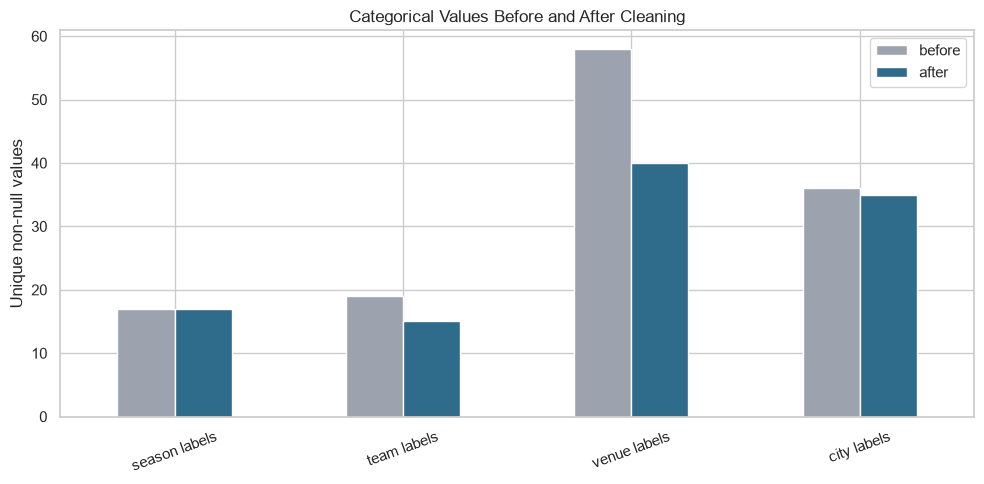

In [11]:
before_after = pd.DataFrame({"measure": ["match rows", "delivery rows", "season labels", "team labels", "venue labels", "city labels", "missing city values"], "before": [len(matches_raw), len(deliveries_raw), matches_raw["season"].nunique(), len(set(matches_raw["team1"]) | set(matches_raw["team2"])), matches_raw["venue"].nunique(), matches_raw["city"].nunique(), matches_raw["city"].isna().sum()], "after": [len(matches_clean), len(deliveries_clean), matches_clean["season_standard"].nunique(), len(set(matches_clean["team1_standard"]) | set(matches_clean["team2_standard"])), matches_clean["venue_standard"].nunique(), matches_clean["city_standard"].nunique(), matches_clean["city_standard"].isna().sum()]})
before_after["change"] = before_after["after"] - before_after["before"]
display(before_after)
category_profile = before_after.loc[before_after["measure"].isin(["season labels", "team labels", "venue labels", "city labels"])]
category_profile.set_index("measure")[["before", "after"]].plot.bar(figsize=(10, 5), color=["#9CA3AF", "#2F6B8A"])
plt.title("Categorical Values Before and After Cleaning"); plt.xlabel(""); plt.ylabel("Unique non-null values"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 13. Validation checks

Validation covers row counts, keys, dates, documented mappings, run arithmetic, wicket consistency, legal-ball logic, and cross-table team/referential integrity. Export is blocked if any check fails.

In [12]:
validation_results = validate_cleaned_data(matches_clean, deliveries_clean)
display(validation_results)
failed_checks = validation_results.loc[validation_results["status"].eq("FAIL")]
assert failed_checks.empty, f"Cleaning validation failed:\n{failed_checks.to_string(index=False)}"
print(f"Validation result: {len(validation_results)} of {len(validation_results)} checks passed.")

,check,status,issue_count
0,"Match row count remains 1,095",PASS,0
1,"Delivery row count remains 260,920",PASS,0
2,Match IDs are unique,PASS,0
3,Participating teams are non-null,PASS,0
4,Winners are participating teams when present,PASS,0
5,Toss winners are participating teams,PASS,0
6,All match dates parsed,PASS,0
7,Season labels remain in the observed domain,PASS,0
8,Only documented team mappings were applied,PASS,0
9,Delivery match IDs are non-null,PASS,0


Validation result: 21 of 21 checks passed.


## 14. Export cleaned datasets

Only `matches_clean.csv` and `deliveries_clean.csv` are written to `data/processed`. They are immediately read back to verify usability and row counts.

In [13]:
matches_output, deliveries_output = save_clean_data(matches_clean, deliveries_clean, PROJECT_ROOT)
matches_readback = pd.read_csv(matches_output, parse_dates=["match_date"], low_memory=False)
deliveries_readback = pd.read_csv(deliveries_output, low_memory=False)
assert matches_readback.shape == matches_clean.shape
assert deliveries_readback.shape == deliveries_clean.shape
assert matches_readback["match_date"].notna().all()
assert set(deliveries_readback["match_id"]) <= set(matches_readback["match_id"])
raw_hashes_after = {name: sha256(path) for name, path in raw_paths.items()}
assert raw_hashes_after == raw_hashes_before
display(pd.DataFrame({"rows": [len(matches_readback), len(deliveries_readback)], "columns": [matches_readback.shape[1], deliveries_readback.shape[1]]}, index=["matches_clean.csv", "deliveries_clean.csv"]))
print("Clean CSV read-back: PASS")
print("Raw SHA-256 comparison: PASS")

,rows,columns
matches_clean.csv,1095,32
deliveries_clean.csv,260920,21


Clean CSV read-back: PASS
Raw SHA-256 comparison: PASS


## 15. Cleaning decisions and limitations

- Raw audit columns remain for standardized season, date, city, venue, and team fields.
- Four team mappings are consistent across both tables; distinct franchises are not merged.
- Eighteen conservative venue aliases are mapped; broader historical stadium renames remain separate.
- Bangalore becomes Bengaluru; 33 Dubai and 18 Sharjah cities are filled from venue context.
- Other conditional nulls remain meaningful.
- Legal deliveries exclude wides and no-balls; recorded ball labels do not determine legality.
- Player names are not standardized because no stable player ID exists.
- No performance metrics or rankings are created.

## 16. Phase 5 handoff

Phase 5 should turn these checks into a reusable data-quality reporting layer, expand defensible domain validation, and report PASS/FAIL results for pipeline runs without changing Phase 4 transformations.